In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    zoom_range=0.4,
    width_shift_range=0.3,
    height_shift_range=0.3,
    brightness_range=[0.7, 1.3],
    shear_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='constant'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
train_generator = train_datagen.flow_from_directory(
    'Dataset1/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    'Dataset1/valid',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    'Dataset1/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 10000 images belonging to 2 classes.
Found 10000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization, Concatenate, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50

# --- Spatial Attention Layer ---
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = tf.keras.layers.Conv2D(1, kernel_size=5, padding='same', activation='sigmoid')
        self.bn = tf.keras.layers.BatchNormalization()
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        attention = self.bn(attention)
        return inputs * attention

# --- Squeeze-and-Excitation Layer ---
class SqueezeExcite(tf.keras.layers.Layer):
    def __init__(self, ratio=16):
        super(SqueezeExcite, self).__init__()
        self.ratio = ratio
    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.global_pool = GlobalAveragePooling2D()
        self.reshape = Reshape((1, 1, self.channels))
        self.dense1 = Dense(self.channels // self.ratio, activation='gelu', use_bias=False)
        self.dense2 = Dense(self.channels, activation='sigmoid', use_bias=False)
        self.multiply = tf.keras.layers.Multiply()
        super(SqueezeExcite, self).build(input_shape)
    def call(self, inputs):
        x = self.global_pool(inputs)
        x = self.reshape(x)
        x = self.dense1(x)
        x = self.dense2(x)
        return self.multiply([inputs, x])

# --- Combined Model ---
def build_combined_model(img_size=224):
    input_tensor = Input(shape=(img_size, img_size, 3))

    # Shared ResNet50 backbone
    base = ResNet50(include_top=False, weights='imagenet', input_tensor=input_tensor)
    for layer in base.layers[:150]:
        layer.trainable = False
    for layer in base.layers[150:]:
        layer.trainable = True
    features = base.output

    # Branch 1: Spatial Attention
    x1 = SpatialAttention()(features)
    x1 = GlobalAveragePooling2D()(x1)
    x1 = Dropout(0.5)(x1)
    x1 = Dense(128, activation='swish', kernel_regularizer=l2(0.001))(x1)
    x1 = BatchNormalization()(x1)

    # Branch 2: Squeeze-and-Excitation
    x2 = SqueezeExcite(ratio=16)(features)
    x2 = GlobalAveragePooling2D()(x2)
    x2 = Dropout(0.5)(x2)
    x2 = Dense(128, activation='gelu', kernel_regularizer=l2(0.001))(x2)
    x2 = BatchNormalization()(x2)

    # Combine both branches
    merged = Concatenate()([x1, x2])
    merged = Dropout(0.5)(merged)
    output = Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))(merged)

    model = Model(inputs=input_tensor, outputs=output)
    return model

In [14]:
model = build_combined_model( )
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 24,637,880 (93.99 MB)

 Trainable params: 11,039,798 (42.11 MB)

 Non-trainable params: 13,598,082 (51.87 MB)

In [17]:
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

optimizers = [
    Adam(learning_rate=1e-4),
    RMSprop(learning_rate=1e-4),
    SGD(learning_rate=1e-4, momentum=0.9)
]

best_val_loss = float('inf')
best_optimizer = None
best_history = None

for opt in optimizers:
    print(f"Testing optimizer: {opt.name}")  # Use .name, not ._name
    # or: print(f"Testing optimizer: {type(opt).__name__}")
    model = build_combined_model(img_size=224)
    model.compile(
        loss='binary_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=10,
        verbose=1
    )
    val_loss = min(history.history['val_loss'])
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_optimizer = opt
        best_history = history

print(f"Best optimizer: {best_optimizer.name} with val_loss: {best_val_loss}")
# or: print(f"Best optimizer: {type(best_optimizer).__name__} with val_loss: {best_val_loss}")

Testing optimizer: adam
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1319s 4s/step - accuracy: 0.5429 - loss: 1.4266 - val_accuracy: 0.6255 - val_loss: 1.1190
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1266s 4s/step - accuracy: 0.6336 - loss: 1.2350 - val_accuracy: 0.6814 - val_loss: 1.0405
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1268s 4s/step - accuracy: 0.6510 - loss: 1.1550 - val_accuracy: 0.7054 - val_loss: 0.9664
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1224s 4s/step - accuracy: 0.6745 - loss: 1.1070 - val_accuracy: 0.7806 - val_loss: 0.8446
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1231s 4s/step - accuracy: 0.6933 - loss: 1.0475 - val_accuracy: 0.7451 - val_loss: 0.8853
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1226s 4s/step - accuracy: 0.7128 - loss: 0.9916 - val_accuracy: 0.7429 - val_loss: 0.8533
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1245s 4s/step - accuracy: 0.7241 - loss: 0.9662 - val_accuracy: 0.6616 - val_loss: 0.9605
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1241s 4s/step - accuracy: 

In [29]:
IMG_SIZE = 128

train_generator = train_datagen.flow_from_directory(
    'Dataset1/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    'Dataset1/valid',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    'Dataset1/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 10000 images belonging to 2 classes.
Found 10000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [30]:
# Get predictions
y_true = test_generator.classes
y_probs = model.predict(test_generator, verbose=0)
y_pred = (y_probs > 0.5).astype(int).reshape(-1)

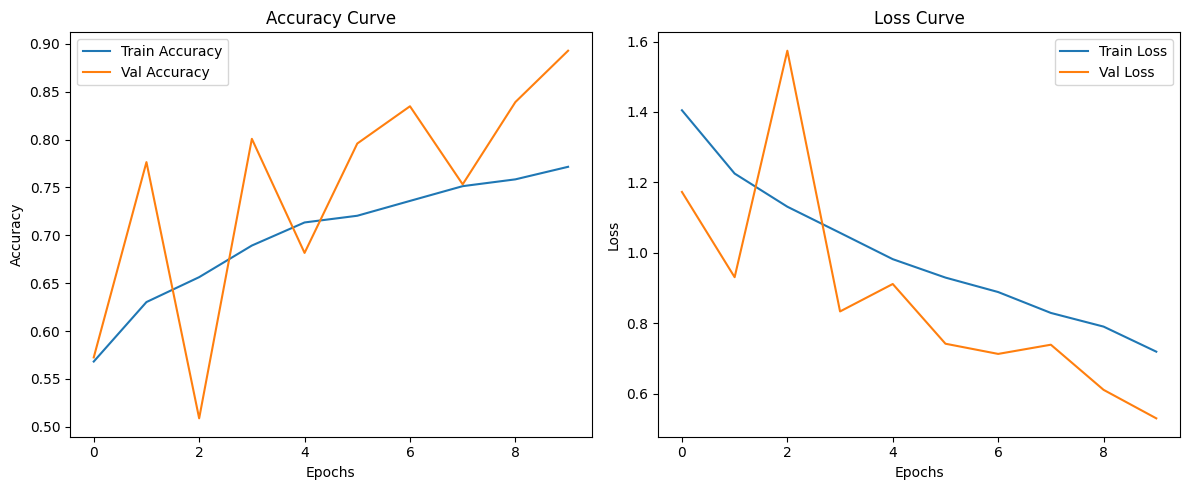

In [31]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-Cancerous', 'Cancerous']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"Specificity: {specificity:.4f}")

Classification Report:
               precision    recall  f1-score   support

Non-Cancerous       0.50      1.00      0.67       250
    Cancerous       0.00      0.00      0.00       250

     accuracy                           0.50       500
    macro avg       0.25      0.50      0.33       500
 weighted avg       0.25      0.50      0.33       500

Specificity: 1.0000


C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

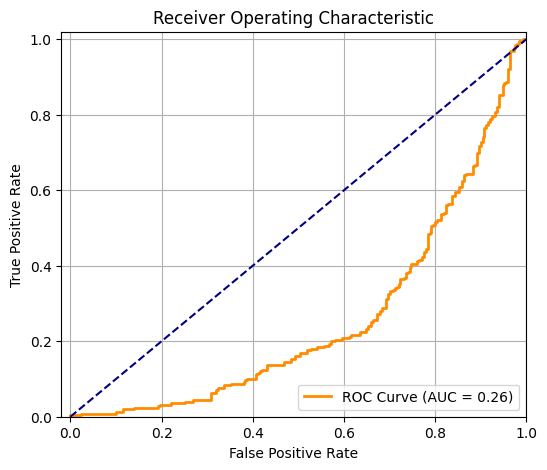

In [33]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [34]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, BatchNormalization, Concatenate, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50

# --- Spatial Attention Layer ---
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = tf.keras.layers.Conv2D(1, kernel_size=5, padding='same', activation='sigmoid')
        self.bn = tf.keras.layers.BatchNormalization()
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        attention = self.bn(attention)
        return inputs * attention

# --- Squeeze-and-Excitation Layer ---
class SqueezeExcite(tf.keras.layers.Layer):
    def __init__(self, ratio=16):
        super(SqueezeExcite, self).__init__()
        self.ratio = ratio
    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.global_pool = GlobalAveragePooling2D()
        self.reshape = Reshape((1, 1, self.channels))
        self.dense1 = Dense(self.channels // self.ratio, activation='gelu', use_bias=False)
        self.dense2 = Dense(self.channels, activation='sigmoid', use_bias=False)
        self.multiply = tf.keras.layers.Multiply()
        super(SqueezeExcite, self).build(input_shape)
    def call(self, inputs):
        x = self.global_pool(inputs)
        x = self.reshape(x)
        x = self.dense1(x)
        x = self.dense2(x)
        return self.multiply([inputs, x])

# --- Combined Model ---
def build_combined_model(img_size=224):
    input_tensor = Input(shape=(img_size, img_size, 3))

    # Shared ResNet50 backbone
    base = ResNet50(include_top=False, weights='imagenet', input_tensor=input_tensor)
    for layer in base.layers[:150]:
        layer.trainable = False
    for layer in base.layers[150:]:
        layer.trainable = True
    features = base.output

    # Branch 1: Spatial Attention
    x1 = SpatialAttention()(features)
    x1 = GlobalAveragePooling2D()(x1)
    x1 = Dropout(0.5)(x1)
    x1 = Dense(128, activation='swish', kernel_regularizer=l2(0.001))(x1)
    x1 = BatchNormalization()(x1)

    # Branch 2: Squeeze-and-Excitation
    x2 = SqueezeExcite(ratio=16)(features)
    x2 = GlobalAveragePooling2D()(x2)
    x2 = Dropout(0.5)(x2)
    x2 = Dense(128, activation='gelu', kernel_regularizer=l2(0.001))(x2)
    x2 = BatchNormalization()(x2)

    # Combine both branches
    merged = Concatenate()([x1, x2])
    merged = Dropout(0.5)(merged)
    output = Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))(merged)

    model = Model(inputs=input_tensor, outputs=output)
    return model

In [37]:
IMG_SIZE = 224

train_generator = train_datagen.flow_from_directory(
    'Dataset1/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    'Dataset1/valid',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    'Dataset1/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 10000 images belonging to 2 classes.
Found 10000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [38]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Build and compile the model
model = build_combined_model(img_size=224)
model.compile(
    optimizer=RMSprop(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    ModelCheckpoint("resnet_se&sa_model.keras", save_best_only=True, verbose=1)
]

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,  # You can increase or adjust
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5487 - loss: 1.4469
Epoch 1: val_loss improved from inf to 1.23474, saving model to resnet_se&sa_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 1446s 5s/step - accuracy: 0.5488 - loss: 1.4466 - val_accuracy: 0.5419 - val_loss: 1.2347 - learning_rate: 1.0000e-04
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6263 - loss: 1.2419
Epoch 2: val_loss improved from 1.23474 to 0.87554, saving model to resnet_se&sa_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 1315s 4s/step - accuracy: 0.6263 - loss: 1.2418 - val_accuracy: 0.8063 - val_loss: 0.8755 - learning_rate: 1.0000e-04
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6726 - loss: 1.1235
Epoch 3: val_loss improved from 0.87554 to 0.82452, saving model to resnet_se&sa_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 1285s 4s/step - accuracy: 0.6726 - loss: 1.1235 - val_accuracy: 0.8085 - val_loss: 0.8245 - learning_rate: 1.0000e-04
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 

In [39]:
class_indices = train_generator.class_indices
labels = {v: k for k, v in class_indices.items()}

In [40]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(model, img_path, labels, img_size=224):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Rescale same as training
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Predict
    prob = model.predict(img_array)[0][0]
    pred_class = 1 if prob >= 0.5 else 0  # Threshold for binary classification

    print(f"Prediction probability: {prob:.4f}")
    print(f"Predicted class: {labels[pred_class]}")
    return labels[pred_class]

In [41]:
# Get the label mapping from your generator
labels = {v: k for k, v in train_generator.class_indices.items()}

# Predict on a new image
img_path = 'Dataset1/test/colon_n/colonn1912.jpeg'
predicted_label = predict_image(model, img_path, labels, img_size=IMG_SIZE)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction probability: 0.9994
Predicted class: colon_n


In [46]:
# Get the label mapping from your generator
labels = {v: k for k, v in train_generator.class_indices.items()}

# Predict on a new image
img_path = 'Dataset1/test/colon_aca/colonca1874.jpeg'
predicted_label = predict_image(model, img_path, labels, img_size=IMG_SIZE)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Prediction probability: 0.0204
Predicted class: colon_aca


In [47]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels
y_true = test_generator.classes

# Get model predictions (probabilities)
y_pred_probs = model.predict(test_generator)
# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step


In [48]:
# Get label mapping from your generator
labels = list(test_generator.class_indices.keys())

In [49]:
print(classification_report(y_true, y_pred, target_names=labels))

              precision    recall  f1-score   support

   colon_aca       0.88      0.95      0.91       250
     colon_n       0.95      0.87      0.91       250

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



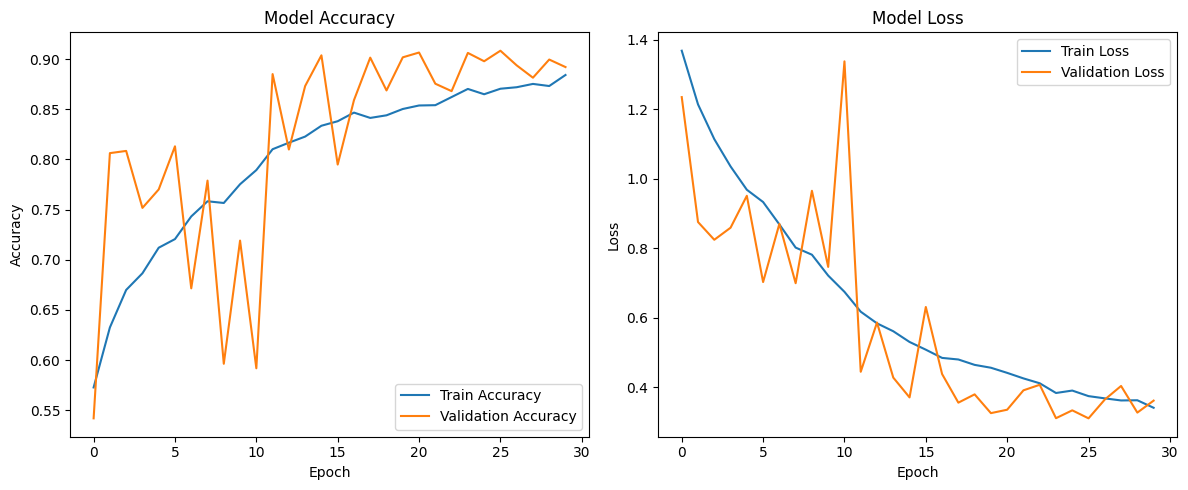

In [50]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [51]:
test_labels = test_generator.classes

In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"Specificity: {specificity:.4f}")

[[238  12]
 [ 33 217]]
Specificity: 0.9520


Enter image path Dataset1/test/colon_n/colonn1777.jpeg


C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\layer.py:361: UserWarning: `build()` was called on layer 'spatial_attention_17', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


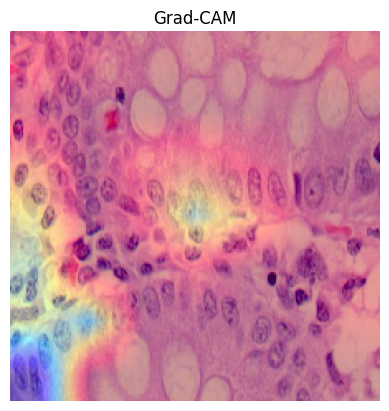

In [58]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

# --- 1. User provides image path ---
image_path = input("Enter image path")

# --- 2. Preprocess the image ---
IMG_SIZE = 224  # Change if your model uses a different input size
def preprocess_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

img_array = preprocess_image(image_path)

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

# --- Define SpatialAttention here ---
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.conv = tf.keras.layers.Conv2D(1, kernel_size=5, padding='same', activation='sigmoid')
        self.bn = tf.keras.layers.BatchNormalization()
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        attention = self.bn(attention)
        return inputs * attention

# --- Now load your model with custom_objects ---
model = tf.keras.models.load_model('resnet50_spatial_attention_final.keras',
                                  custom_objects={'SpatialAttention': SpatialAttention})
# For demonstration, suppose your model is already loaded as "model"
# Replace 'conv5_block3_out' with your last conv layer name from model.summary()
last_conv_layer_name = 'conv5_block3_out'  # Update as needed

# --- 4. Grad-CAM function ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- 5. Generate and display Grad-CAM heatmap ---
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Resize heatmap to original image size
heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Overlay heatmap on original image
orig_img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
orig_img = tf.keras.utils.img_to_array(orig_img).astype(np.uint8)
superimposed_img = cv2.addWeighted(orig_img, 0.6, heatmap_color, 0.4, 0)

plt.imshow(superimposed_img.astype(np.uint8))
plt.axis('off')
plt.title('Grad-CAM')
plt.show()

C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\layer.py:361: UserWarning: `build()` was called on layer 'spatial_attention_14', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Enter image path:  Dataset1/test/colon_n/colonn1777.jpeg


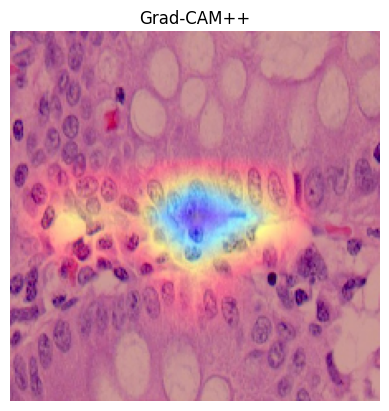

In [55]:
# 1. Install tf-keras-vis if you haven't already
# !pip install tf-keras-vis

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

# --- Define SpatialAttention here ---
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.conv = tf.keras.layers.Conv2D(1, kernel_size=5, padding='same', activation='sigmoid')
        self.bn = tf.keras.layers.BatchNormalization()
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        attention = self.bn(attention)
        return inputs * attention

# --- 2. Load your model ---
model = tf.keras.models.load_model('resnet50_spatial_attention_final.keras',
                                  custom_objects={'SpatialAttention': SpatialAttention})

# --- 3. Preprocess the image ---
IMG_SIZE = 224
image_path = input("Enter image path: ")
def preprocess_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

img_array = preprocess_image(image_path)

# --- 4. Grad-CAM++ using tf-keras-vis ---
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

# Find your last conv layer name from model.summary()
last_conv_layer_name = 'conv5_block3_out'  # Update to match your model

# For binary classification, use CategoricalScore([0]) or CategoricalScore([1])
score = CategoricalScore([0])  # Change to [1] for the other class if needed

# Create GradCAM++ object
gradcam_pp = GradcamPlusPlus(model, model_modifier=ReplaceToLinear())

# Generate heatmap
cam = gradcam_pp(score, img_array, penultimate_layer=last_conv_layer_name)

# --- 5. Display the Grad-CAM++ heatmap overlay ---
# cam shape: (1, IMG_SIZE, IMG_SIZE)
heatmap = cam[0]
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Load original image for overlay
orig_img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
orig_img = tf.keras.utils.img_to_array(orig_img).astype(np.uint8)
superimposed_img = cv2.addWeighted(orig_img, 0.6, heatmap_color, 0.4, 0)

plt.imshow(superimposed_img.astype(np.uint8))
plt.axis('off')
plt.title('Grad-CAM++')
plt.show()

C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\layer.py:361: UserWarning: `build()` was called on layer 'spatial_attention_15', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Enter image path:  Dataset1/test/colon_n/colonn1777.jpeg


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

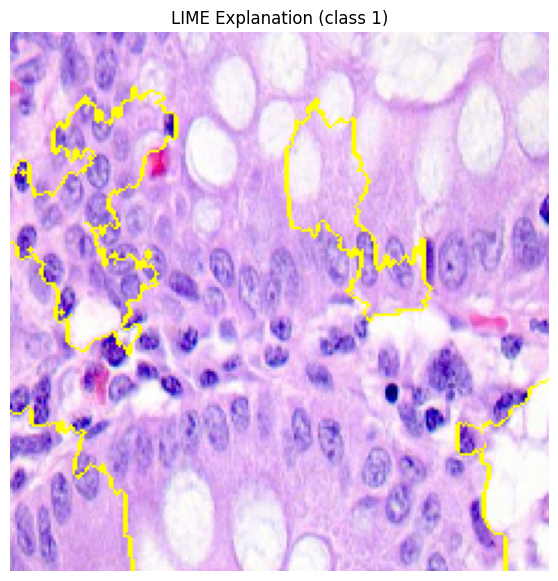

In [56]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
import cv2

# --- Define SpatialAttention here if needed ---
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.conv = tf.keras.layers.Conv2D(1, kernel_size=5, padding='same', activation='sigmoid')
        self.bn = tf.keras.layers.BatchNormalization()
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        attention = self.bn(attention)
        return inputs * attention

# --- Load your model ---
model = tf.keras.models.load_model('resnet50_spatial_attention_final.keras',
                                  custom_objects={'SpatialAttention': SpatialAttention})

# --- Preprocess the image ---
IMG_SIZE = 224
image_path = input("Enter image path: ")
def preprocess_image_for_model(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    return img_array

img = preprocess_image_for_model(image_path)

# --- LIME expects images in [0,255] uint8 for segmentation ---
img_uint8 = (img * 255).astype(np.uint8)

# --- Define prediction function for LIME ---
def predict_fn(images):
    # images: list of images in [0,255], shape (N, H, W, 3), uint8
    # Model expects float32 in [0,1]
    images = np.array(images).astype(np.float32) / 255.0
    preds = model.predict(images)
    # For binary classification, return 2 columns: [1-p, p]
    if preds.shape[-1] == 1:
        preds = np.concatenate([1 - preds, preds], axis=1)
    return preds

# --- Create LIME ImageExplainer ---
explainer = lime_image.LimeImageExplainer()

# --- Explain the prediction for this image ---
explanation = explainer.explain_instance(
    img_uint8, 
    predict_fn, 
    top_labels=2, 
    hide_color=0, 
    num_samples=1000
)

# --- Choose the class to explain (e.g., predicted class) ---
predicted_class = np.argmax(predict_fn([img_uint8])[0])

# --- Get image and mask for visualization ---
temp, mask = explanation.get_image_and_mask(
    predicted_class, 
    positive_only=True, 
    num_features=8, 
    hide_rest=False
)

# --- Display LIME explanation ---
plt.figure(figsize=(7,7))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f'LIME Explanation (class {predicted_class})')
plt.axis('off')
plt.show()

C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\layer.py:361: UserWarning: `build()` was called on layer 'spatial_attention_16', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Enter image path:  Dataset1/test/colon_n/colonn1777.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


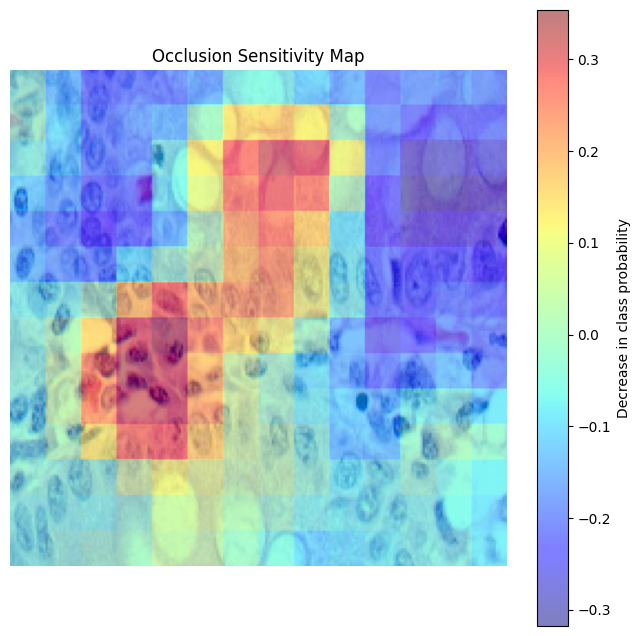

In [57]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# --- 1. Load your model and preprocess the image as before ---
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.conv = tf.keras.layers.Conv2D(1, kernel_size=5, padding='same', activation='sigmoid')
        self.bn = tf.keras.layers.BatchNormalization()
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        attention = self.bn(attention)
        return inputs * attention

model = tf.keras.models.load_model('resnet50_spatial_attention_final.keras',
                                  custom_objects={'SpatialAttention': SpatialAttention})

IMG_SIZE = 224
image_path = input("Enter image path: ")

def preprocess_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    return img_array

orig_img = preprocess_image(image_path)

# --- 2. Occlusion Sensitivity Function ---
def occlusion_sensitivity(model, image, class_index, mask_size=32, stride=16, occlusion_value=0.0):
    """
    Args:
        model: Keras model
        image: numpy array, shape (H, W, 3), values in [0,1]
        class_index: int, index of class to analyze
        mask_size: int, size of square mask (pixels)
        stride: int, stride of mask (pixels)
        occlusion_value: float, value to fill in occluded region (e.g., 0.0 for black)
    Returns:
        sensitivity_map: numpy array, shape (H, W)
    """
    H, W, _ = image.shape
    output_map = np.zeros((H, W))
    counts = np.zeros((H, W))
    baseline_pred = model.predict(np.expand_dims(image, axis=0))[0]
    if baseline_pred.shape[-1] == 1:
        baseline_score = baseline_pred[0]  # For sigmoid output
    else:
        baseline_score = baseline_pred[class_index]  # For softmax output

    for y in range(0, H - mask_size + 1, stride):
        for x in range(0, W - mask_size + 1, stride):
            img_occluded = image.copy()
            img_occluded[y:y+mask_size, x:x+mask_size, :] = occlusion_value
            pred = model.predict(np.expand_dims(img_occluded, axis=0))[0]
            if pred.shape[-1] == 1:
                score = pred[0]
            else:
                score = pred[class_index]
            delta = baseline_score - score  # How much occlusion drops the score
            output_map[y:y+mask_size, x:x+mask_size] += delta
            counts[y:y+mask_size, x:x+mask_size] += 1

    # Average over overlapping regions
    sensitivity_map = output_map / np.maximum(counts, 1)
    return sensitivity_map

# --- 3. Run occlusion sensitivity ---
# For binary classification, class_index=0 or 1 depending on which class you want to analyze
class_index = 0  # Change to 1 for the other class if needed
mask_size = 32   # Size of occlusion patch in pixels
stride = 16      # Step size for moving the patch

sens_map = occlusion_sensitivity(model, orig_img, class_index, mask_size=mask_size, stride=stride, occlusion_value=0.0)

# --- 4. Display the occlusion sensitivity map ---
plt.figure(figsize=(8,8))
plt.imshow((orig_img * 255).astype(np.uint8))
plt.imshow(sens_map, cmap='jet', alpha=0.5)
plt.colorbar(label='Decrease in class probability')
plt.title('Occlusion Sensitivity Map')
plt.axis('off')
plt.show()


In [65]:
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class SqueezeExcite(tf.keras.layers.Layer):
    def __init__(self, ratio=16, **kwargs):  # Accept **kwargs here
        super(SqueezeExcite, self).__init__(**kwargs)  # Pass kwargs to superclass
        self.ratio = ratio

    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.reshape = tf.keras.layers.Reshape((1, 1, self.channels))
        self.dense1 = tf.keras.layers.Dense(self.channels // self.ratio, activation='gelu', use_bias=False)
        self.dense2 = tf.keras.layers.Dense(self.channels, activation='sigmoid', use_bias=False)
        self.multiply = tf.keras.layers.Multiply()
        super(SqueezeExcite, self).build(input_shape)

    def call(self, inputs):
        x = self.global_pool(inputs)
        x = self.reshape(x)
        x = self.dense1(x)
        x = self.dense2(x)
        return self.multiply([inputs, x])


In [66]:
@tf.keras.utils.register_keras_serializable()
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.conv = tf.keras.layers.Conv2D(1, kernel_size=5, padding='same', activation='sigmoid')
        self.bn = tf.keras.layers.BatchNormalization()

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention = self.conv(concat)
        attention = self.bn(attention)
        return inputs * attention

C:\Users\nishu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\layer.py:361: UserWarning: `build()` was called on layer 'spatial_attention_20', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━

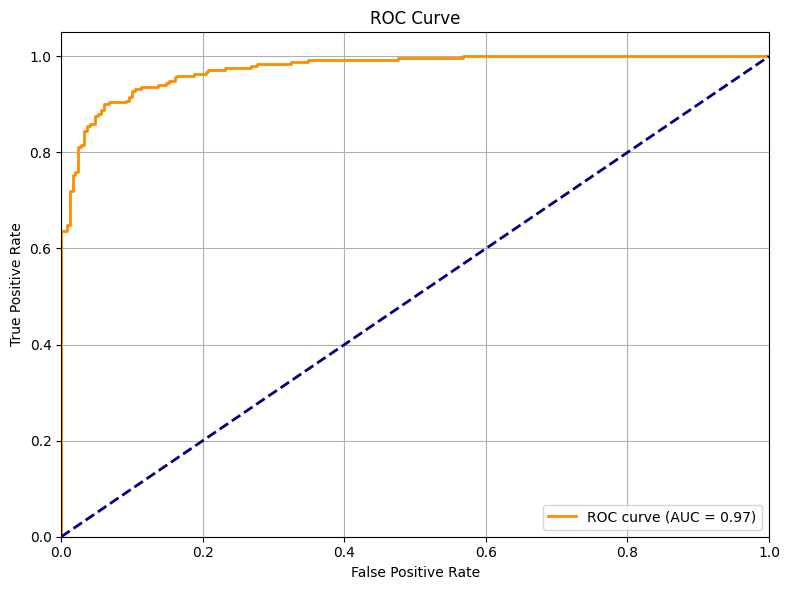

In [67]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import load_model
import os

IMG_SIZE = 224

# --- Define preprocessing ---
def preprocess_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    return img_array

# --- Load model 

model = load_model('resnet_se&sa_model.keras', custom_objects={
    'SpatialAttention': SpatialAttention,
    'SqueezeExcite': SqueezeExcite
})

# --- Load test images and labels ---
test_dir = 'Dataset1/test'
class_names = sorted(os.listdir(test_dir))  # e.g., ['infected', 'non-infected']

image_paths = []
y_true = []

for label_index, class_name in enumerate(class_names):
    class_folder = os.path.join(test_dir, class_name)
    for fname in os.listdir(class_folder):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(class_folder, fname))
            y_true.append(label_index)  # infected=0, non-infected=1 or vice versa based on sorting

# --- Make predictions ---
y_pred = []

for path in image_paths:
    img = preprocess_image(path)
    img = np.expand_dims(img, axis=0)  # model expects batch
    prob = model.predict(img)[0]
    if prob.shape == ():  # if scalar output
        y_pred.append(prob)
    else:  # if shape like [0.3, 0.7]
        y_pred.append(prob[0])  # probability of class 1 (positive class)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Compute ROC curve and AUC ---
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# --- Plot ROC Curve ---
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()